In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [3]:
np.random.seed(0)

time_steps = 500
time = np.arange(time_steps)

data = np.sin(0.02 * time) + np.random.normal(0, 0.1, time_steps)

df = pd.DataFrame(data, columns=["value"])
df.head()


,value
0,0.176405
1,0.060014
2,0.137863
3,0.284053
4,0.266670


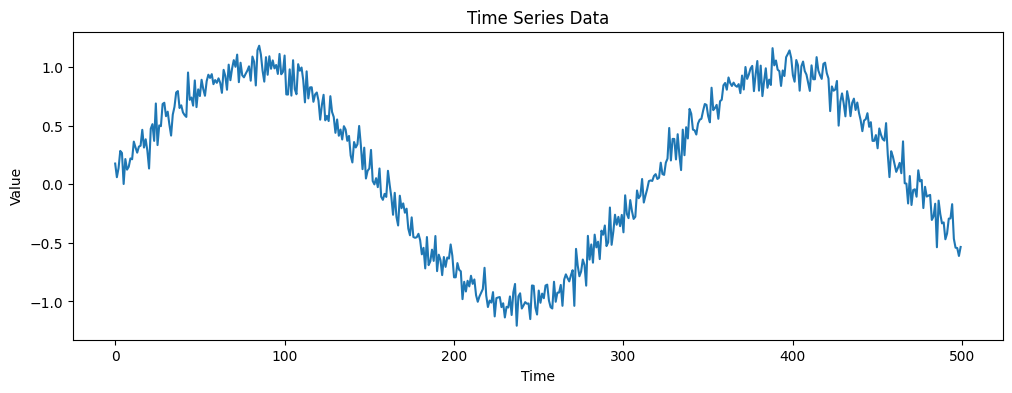

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(df["value"])
plt.title("Time Series Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


In [5]:
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df)


In [6]:
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 20
X, y = create_sequences(scaled_values, window_size)


In [7]:
split_index = int(0.8 * len(X))

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]


In [8]:
model = Sequential()
model.add(LSTM(50, input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.3515 - val_loss: 0.1448
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0291 - val_loss: 0.0167
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0151 - val_loss: 0.0237
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0112 - val_loss: 0.0055
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0060 - val_loss: 0.0018
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0060 - val_loss: 0.0042
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0047 - val_loss: 0.0019
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0039 - val_loss: 0.0021
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0035 - val_loss: 0.0018
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0035 - val_loss: 0.0018
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

In [10]:
predictions = model.predict(X_test)

y_test_original = scaler.inverse_transform(y_test)
predictions_original = scaler.inverse_transform(predictions)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 


In [11]:
rmse = np.sqrt(mean_squared_error(y_test_original, predictions_original))
print("RMSE:", rmse)


RMSE: 0.14880989172965153


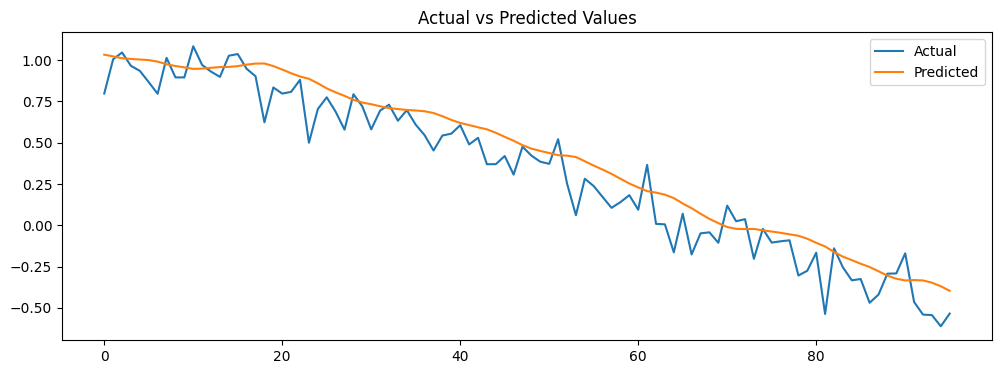

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_original, label="Actual")
plt.plot(predictions_original, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Values")
plt.show()


In [13]:
errors = np.abs(y_test_original - predictions_original)

threshold = np.mean(errors) + 2 * np.std(errors)
anomalies = errors > threshold


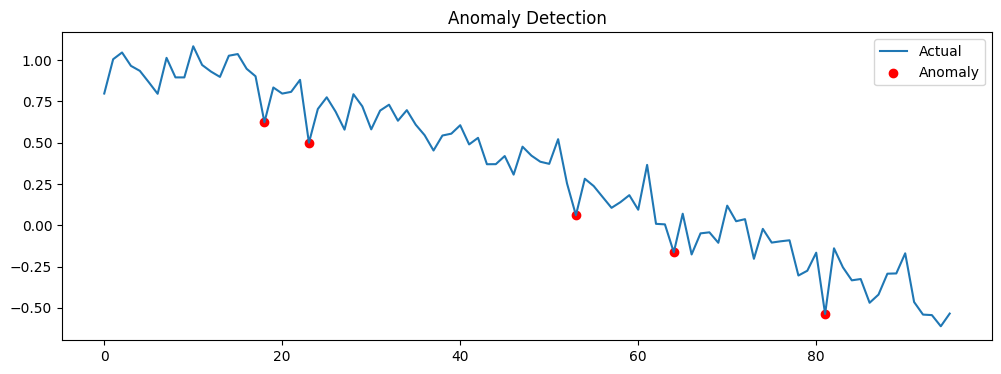

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_original, label="Actual")
plt.scatter(
    np.where(anomalies)[0],
    y_test_original[anomalies],
    color="red",
    label="Anomaly"
)
plt.legend()
plt.title("Anomaly Detection")
plt.show()
